# DATA ALL

Dataset: <xarray.Dataset> Size: 7MB
Dimensions:                             (time: 37331)
Coordinates:
  * time                                (time) datetime64[ns] 299kB 2023-08-0...
Data variables: (12/18)
    serial_number                       (time) <U8 1MB '16221F19' ... '18704C66'
    hops                                (time) float64 299kB ...
    intervals_active                    (time) int64 299kB ...
    mesh_parent                         (time) <U8 1MB ...
    radio_signal_strength_incoming_dbm  (time) float64 299kB ...
    radio_signal_strength_outgoing_dbm  (time) float64 299kB ...
    ...                                  ...
    x_g                                 (time) float64 299kB ...
    y_g                                 (time) float64 299kB ...
    z_g                                 (time) float64 299kB ...
    x_mm_per_m                          (time) float64 299kB ...
    y_mm_per_m                          (time) float64 299kB ...
    z_mm_per_m          

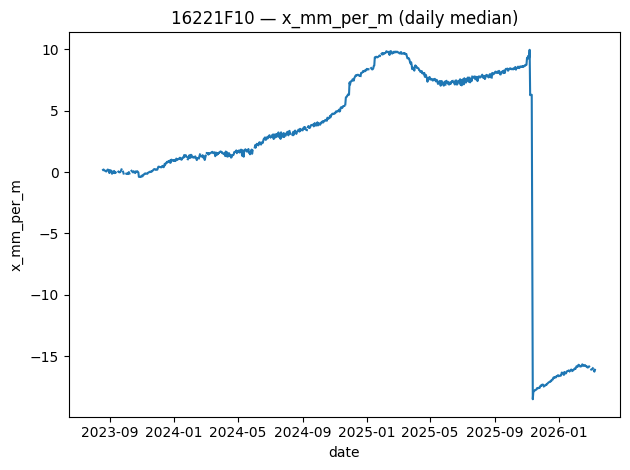

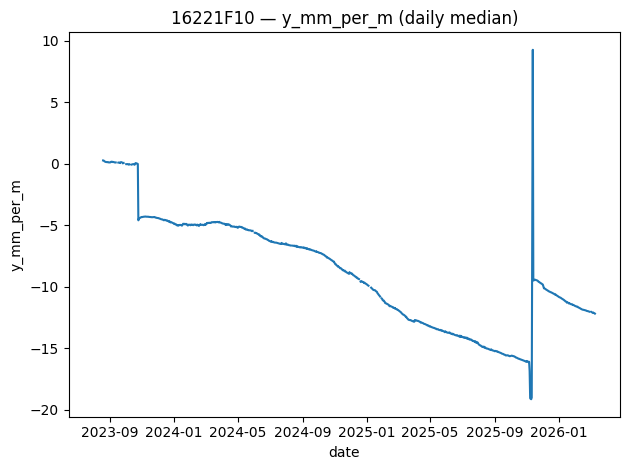

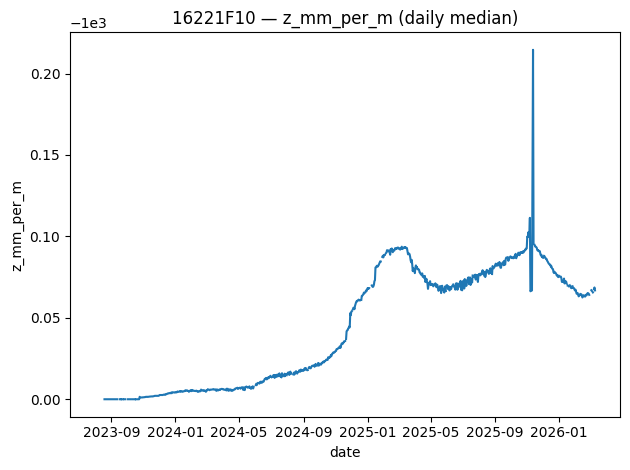

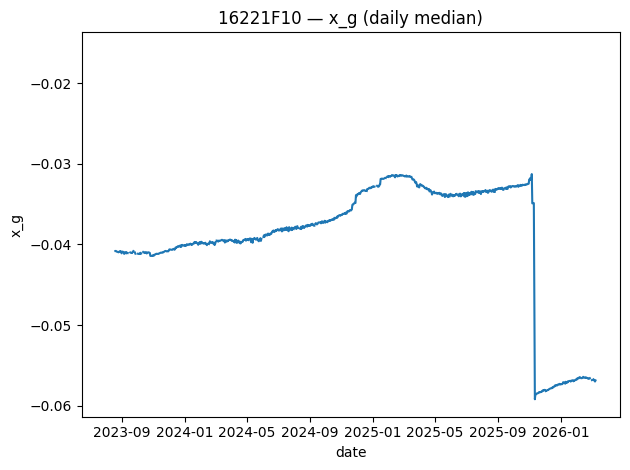

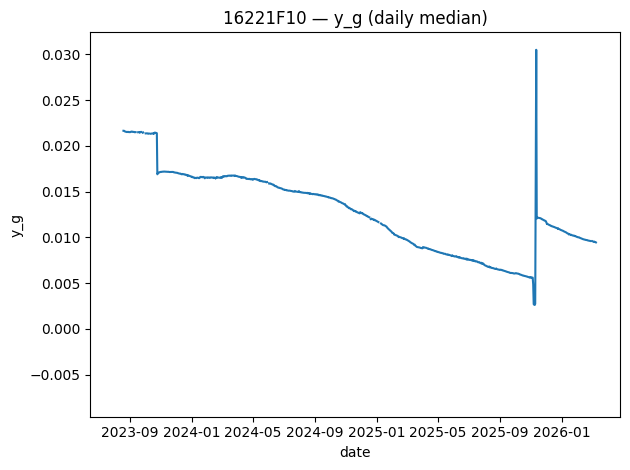

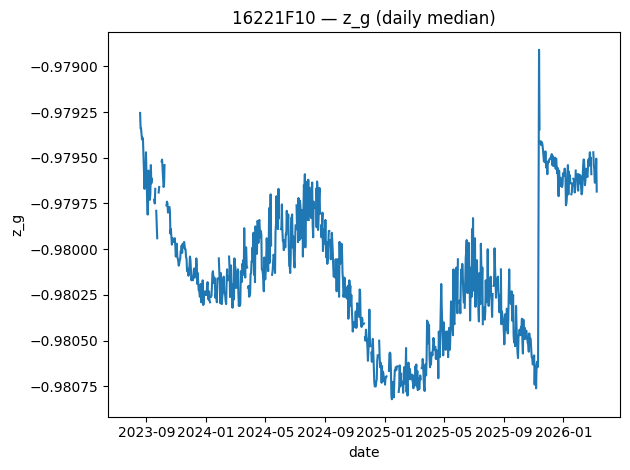

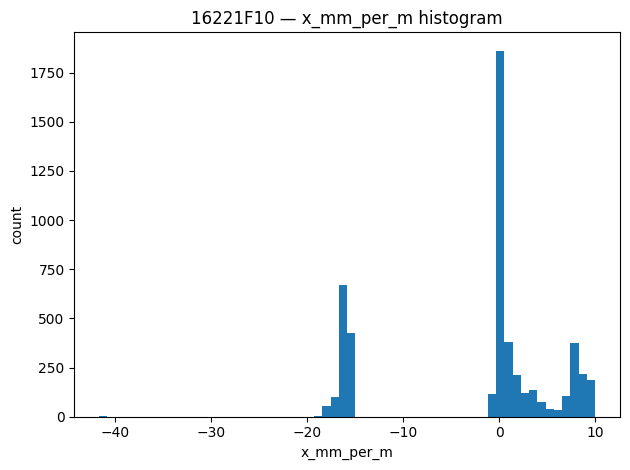

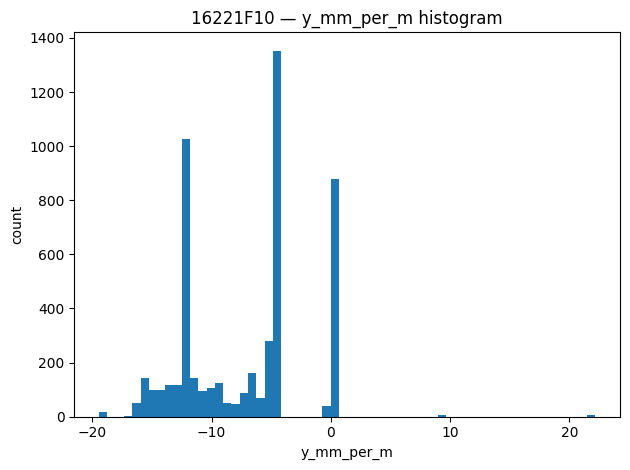

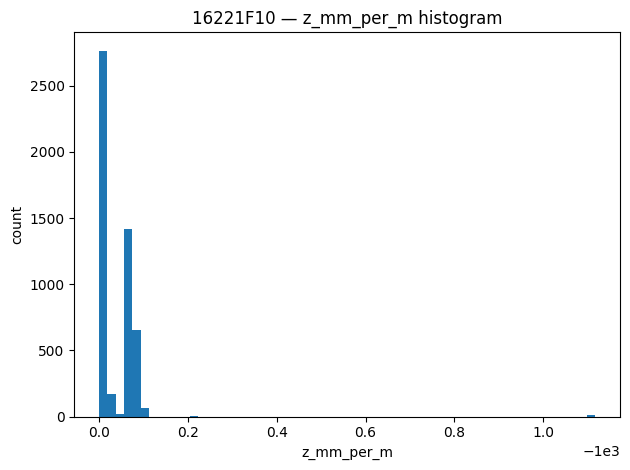

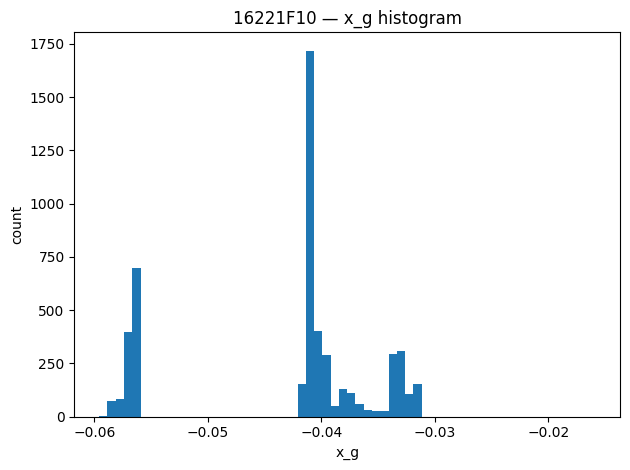

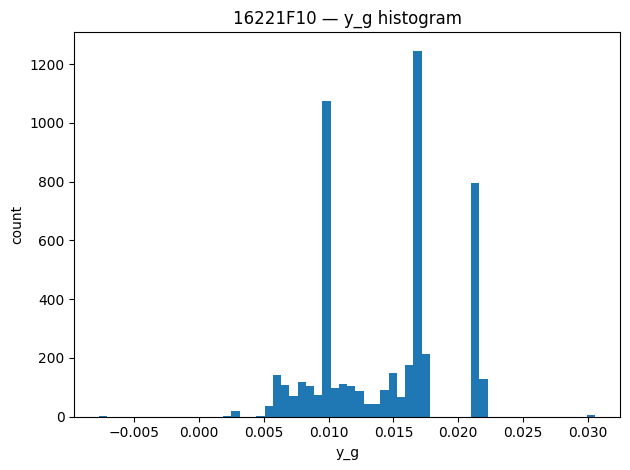

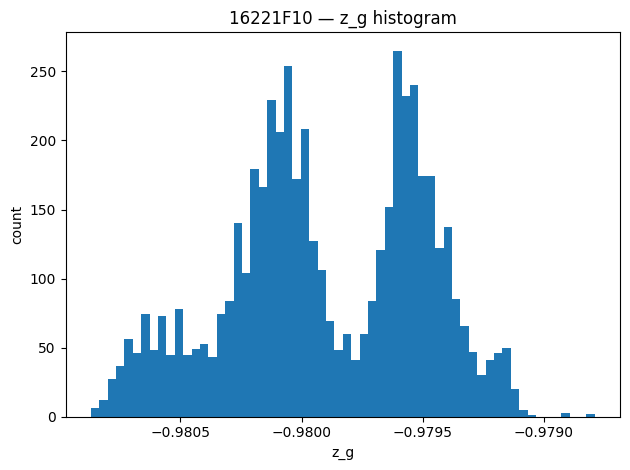


Correlation matrix for 16221F10 (daily medians; vars with <50% missing):
                                    hops  intervals_active  radio_signal_strength_incoming_dbm  radio_signal_strength_outgoing_dbm  packets_queued  type  radio_connection_group  mesh_batt_v  ref_v  temp_c    x_g    y_g    z_g  x_mm_per_m  y_mm_per_m  z_mm_per_m
hops                                 NaN               NaN                                 NaN                                 NaN             NaN   NaN                     NaN          NaN    NaN     NaN    NaN    NaN    NaN         NaN         NaN         NaN
intervals_active                     NaN             1.000                              -0.137                              -0.116             NaN   NaN                     NaN       -0.716 -0.030   0.195  0.727 -0.476 -0.655       0.743      -0.495       0.355
radio_signal_strength_incoming_dbm   NaN            -0.137                               1.000                               0.966          

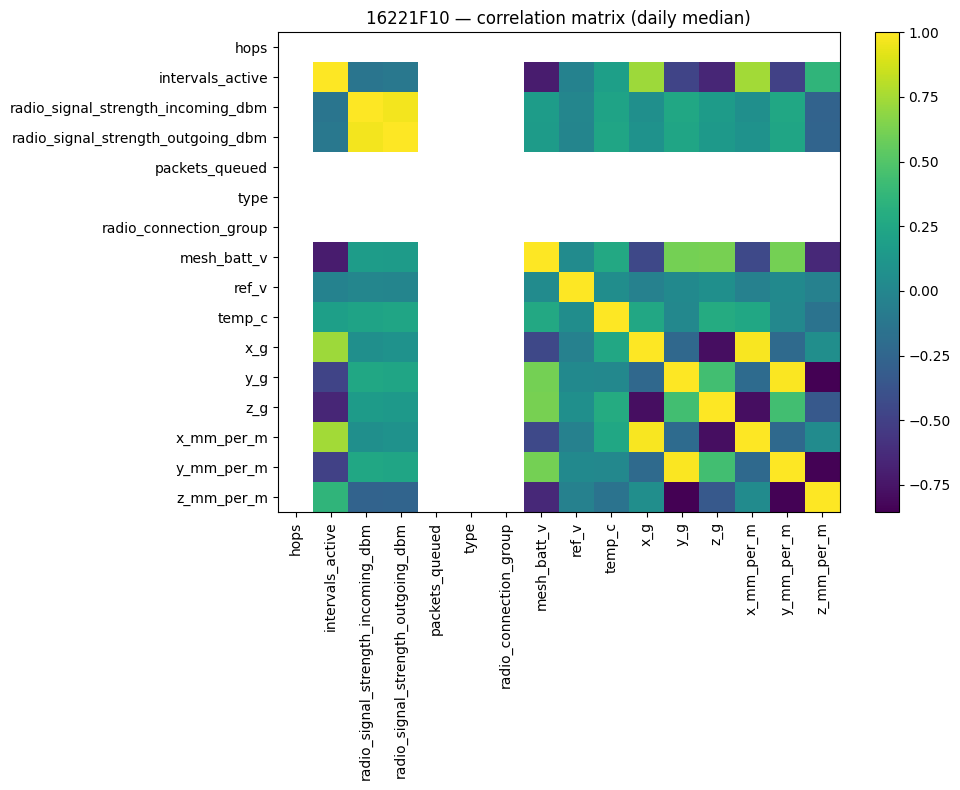

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PATH = "/datassd/proyectos/terravision/terravision_sensor_data/tharsis/tilt/tharsis_tilt.nc"

# ----------------------------
# 1) Load + basic cleaning
# ----------------------------
ds = xr.open_dataset(PATH)

# Drop NaT times, sort by time
time = pd.to_datetime(ds["time"].values)
valid = ~time.isna()
ds = ds.isel(time=valid).sortby("time")

# Drop duplicate timestamps per sensor (keep first)
df0 = ds[["serial_number"]].to_dataframe().reset_index()
dup_mask = df0.duplicated(subset=["serial_number", "time"], keep="first")
if dup_mask.any():
    ds = ds.isel(time=~xr.DataArray(dup_mask.values, dims="time"))

print("Dataset:", ds)
print("\nVariables:", list(ds.data_vars))
print("\nTime range:", pd.to_datetime(ds.time.values[0]), "→", pd.to_datetime(ds.time.values[-1]))
print("N time steps:", ds.sizes["time"])

# Identify variable types
all_vars = list(ds.data_vars)
cat_vars = [v for v in all_vars if ds[v].dtype.kind in {"U", "S", "O"}]
num_vars = [v for v in all_vars if np.issubdtype(ds[v].dtype, np.number)]

print("\nCategorical vars:", cat_vars)
print("Numeric vars:", num_vars)

# ----------------------------
# 2) Sensor inventory
# ----------------------------
df_meta = ds[["serial_number"]].to_dataframe().reset_index()
counts = df_meta["serial_number"].value_counts()

print("\nSensors (serial_number) counts:")
print(counts.to_string())

top_serial = counts.index[0]
print("\nUsing top sensor for plots/corr:", top_serial)

# ----------------------------
# 3) Cadence + gaps (PER SENSOR)
# ----------------------------
gap_threshold = pd.Timedelta(minutes=30)

gap_rows = []
cad_rows = []

for sn in counts.index:
    t_sn = df_meta.loc[df_meta["serial_number"] == sn, "time"].sort_values()
    dt = t_sn.diff().dropna()

    if len(dt) == 0:
        continue

    cad_rows.append({
        "serial_number": sn,
        "n_points": int((df_meta["serial_number"] == sn).sum()),
        "dt_median": dt.median(),
        "dt_p25": dt.quantile(0.25),
        "dt_p75": dt.quantile(0.75),
        "dt_max": dt.max(),
    })

    gaps = dt[dt > gap_threshold].sort_values(ascending=False)
    if len(gaps):
        t_sn = t_sn.reset_index(drop=True)
        dt_pos = t_sn.diff()
        gap_pos = dt_pos[dt_pos > gap_threshold]

        for pos, gap in gap_pos.sort_values(ascending=False).head(10).items():
            time_after = t_sn.iloc[pos]
            time_before = t_sn.iloc[pos - 1] if pos > 0 else pd.NaT

            gap_rows.append({
                "serial_number": sn,
                "gap": str(gap),
                "time_before_gap": time_before,
                "time_after_gap": time_after,
            })

cad_df = pd.DataFrame(cad_rows).sort_values(["dt_median", "serial_number"])
print("\nCadence summary per sensor:")
print(cad_df.to_string(index=False))

if gap_rows:
    gaps_df = pd.DataFrame(gap_rows)
    print(f"\nFound gaps > {gap_threshold} (top 10 per sensor):")
    print(gaps_df.to_string(index=False))
else:
    print(f"\nNo gaps > {gap_threshold} found (per sensor).")

# ----------------------------
# 4) Missingness + stats per variable (NUMERIC ONLY)
# ----------------------------
missing_rows = []
stats_rows = []

for v in num_vars:
    arr = ds[v].values.astype("float64")
    n = arr.size
    n_missing = int(np.isnan(arr).sum())
    missing_pct = (n_missing / n) * 100
    missing_rows.append({"variable": v, "missing_count": n_missing, "missing_pct": missing_pct})

    if n_missing == n:
        stats_rows.append({"variable": v, "dtype": str(ds[v].dtype)})
        continue

    s = pd.Series(arr)
    stats_rows.append({
        "variable": v,
        "dtype": str(ds[v].dtype),
        "min": float(np.nanmin(arr)),
        "p01": float(s.quantile(0.01)),
        "p05": float(s.quantile(0.05)),
        "median": float(np.nanmedian(arr)),
        "mean": float(np.nanmean(arr)),
        "std": float(np.nanstd(arr)),
        "p95": float(s.quantile(0.95)),
        "p99": float(s.quantile(0.99)),
        "max": float(np.nanmax(arr)),
    })

missing_df = pd.DataFrame(missing_rows).sort_values(["missing_pct", "variable"], ascending=[False, True])
stats_df = pd.DataFrame(stats_rows).sort_values("variable")

print("\nMissingness (numeric vars):")
print(missing_df.to_string(index=False))

print("\nStats (numeric vars):")
print(stats_df.to_string(index=False))

# ----------------------------
# 5) Time series plots (daily) — FOR ONE SENSOR
# ----------------------------
preferred_order = [
    # tilt / orientation
    "x_mm_per_m", "y_mm_per_m", "z_mm_per_m",
    "x_g", "y_g", "z_g",
    # device health / comms
    "temp_c", "mesh_batt_v", "ref_v",
    "radio_signal_strength_incoming_dbm", "radio_signal_strength_outgoing_dbm",
    "hops", "packets_queued",
]

good_vars = missing_df.loc[missing_df["missing_pct"] < 100, "variable"].tolist()
plot_vars = [v for v in preferred_order if v in good_vars][:6] or good_vars[:6]

df = ds[["serial_number"] + plot_vars].to_dataframe().reset_index()
df = df[df["serial_number"] == top_serial].set_index("time").sort_index()

for v in plot_vars:
    series = df[v].astype("float64")
    plt.figure()
    daily = series.resample("1D").median()  # median is often nicer for tilt/noise
    plt.plot(daily.index, daily.values)
    plt.title(f"{top_serial} — {v} (daily median)")
    plt.xlabel("date")
    plt.ylabel(v)
    plt.tight_layout()
    plt.show()

# ----------------------------
# 6) Histograms (one sensor)
# ----------------------------
for v in plot_vars:
    s = df[v].dropna()
    if len(s) == 0:
        continue
    plt.figure()
    plt.hist(s.values, bins=60)
    plt.title(f"{top_serial} — {v} histogram")
    plt.xlabel(v)
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()

# ----------------------------
# 7) Correlation matrix (numeric vars with <50% missing) — one sensor
# ----------------------------
missing_map = missing_df.set_index("variable")["missing_pct"].to_dict()
corr_vars = [v for v in num_vars if missing_map.get(v, 100) < 50]

df_corr = ds[["serial_number"] + corr_vars].to_dataframe().reset_index()
df_corr = df_corr[df_corr["serial_number"] == top_serial].drop(columns=["serial_number"]).set_index("time")

# Optional: use daily aggregation to reduce autocorrelation / burstiness
df_daily = df_corr.resample("1D").median()

corr = df_daily.corr(numeric_only=True)

print(f"\nCorrelation matrix for {top_serial} (daily medians; vars with <50% missing):")
print(corr.round(3).to_string())

plt.figure(figsize=(10, 8))
plt.imshow(corr.values, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title(f"{top_serial} — correlation matrix (daily median)")
plt.tight_layout()
plt.show()

# metadata ALL

Dataset: <xarray.Dataset> Size: 4MB
Dimensions:                             (time: 23048)
Coordinates:
  * time                                (time) datetime64[ns] 184kB 2023-08-0...
Data variables: (12/18)
    serial_number                       (time) <U8 738kB '16402035' ... '1640...
    hops                                (time) int64 184kB ...
    intervals_active                    (time) int64 184kB ...
    mesh_parent                         (time) int64 184kB ...
    radio_signal_strength_incoming_dbm  (time) float64 184kB ...
    radio_signal_strength_outgoing_dbm  (time) float64 184kB ...
    ...                                  ...
    radio_signal_sensitivity_dbm        (time) int64 184kB ...
    mesh_radio_relay_factor             (time) int64 184kB ...
    transmit_power_dbm                  (time) int64 184kB ...
    radio_connection_group              (time) int64 184kB ...
    mesh_batt_v                         (time) float64 184kB ...
    temp_c                    

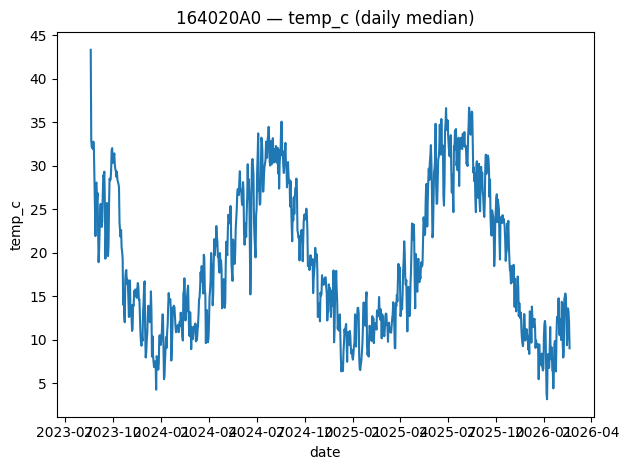

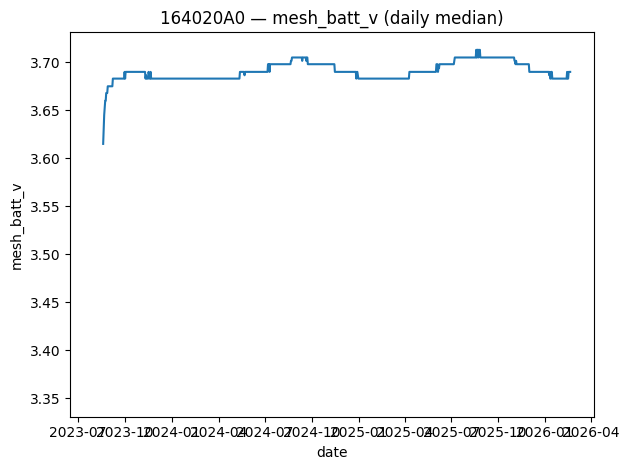

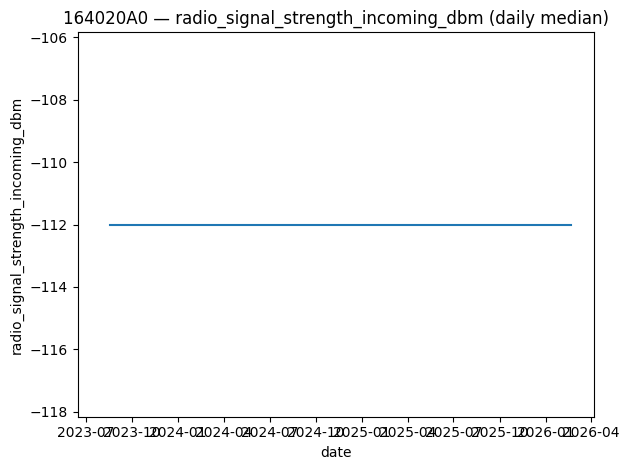

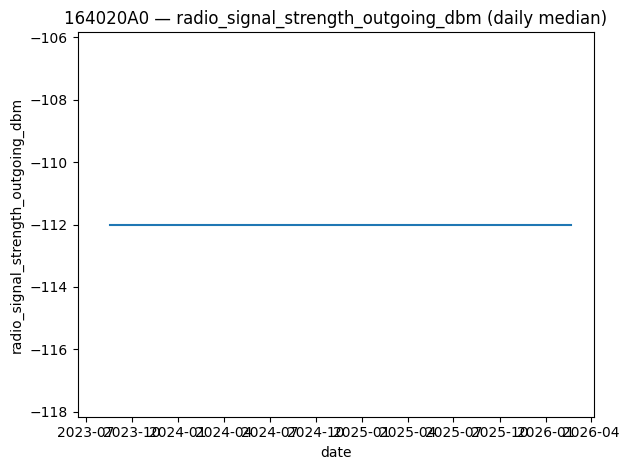

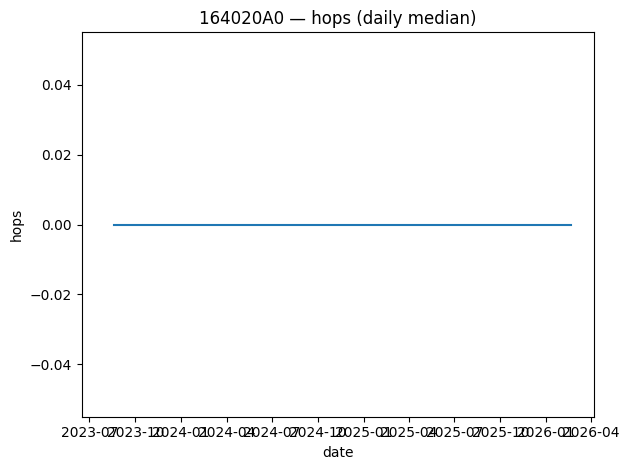

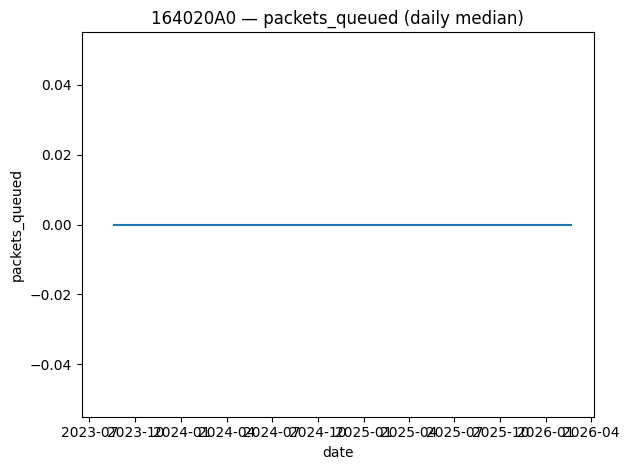

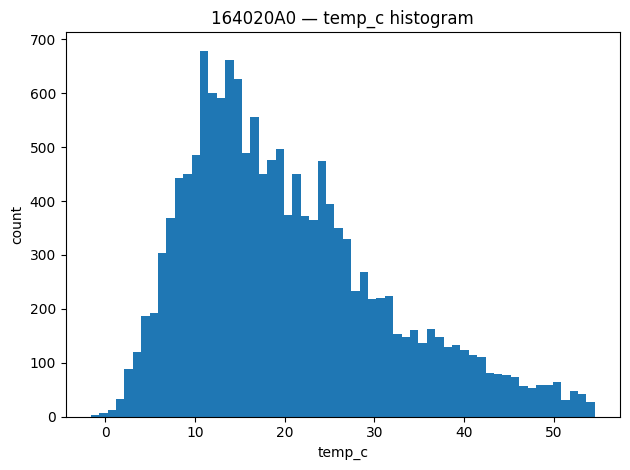

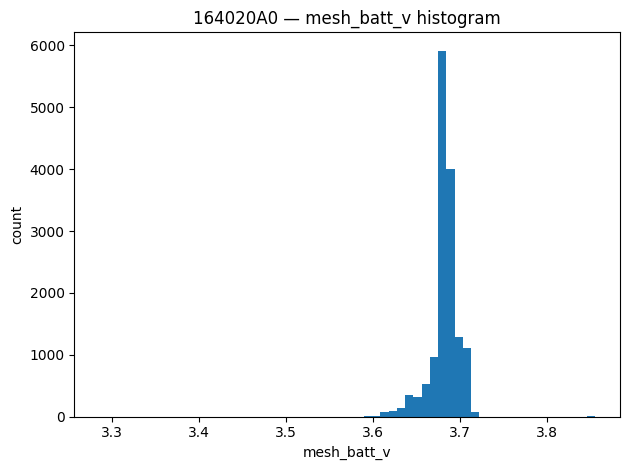

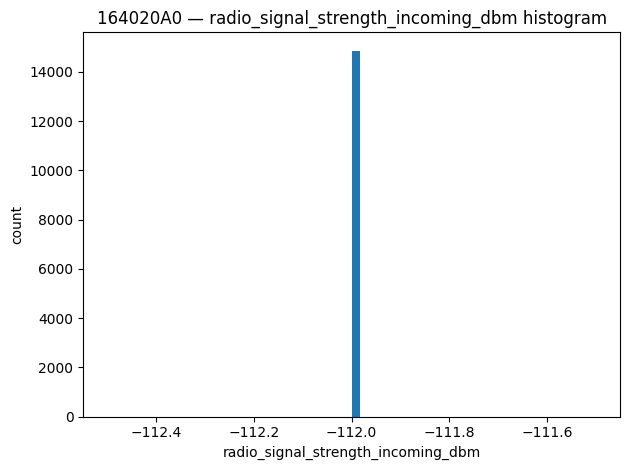

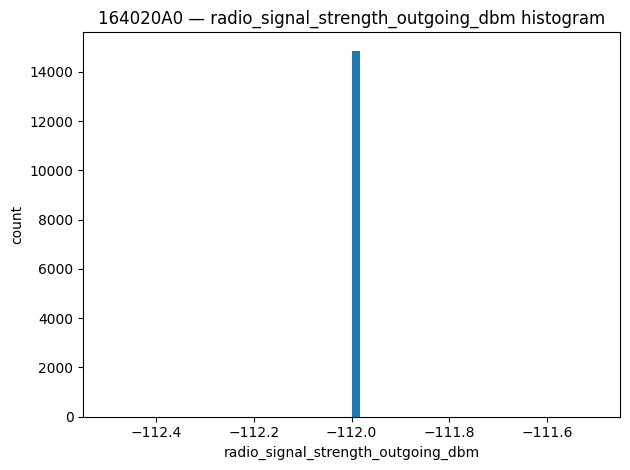

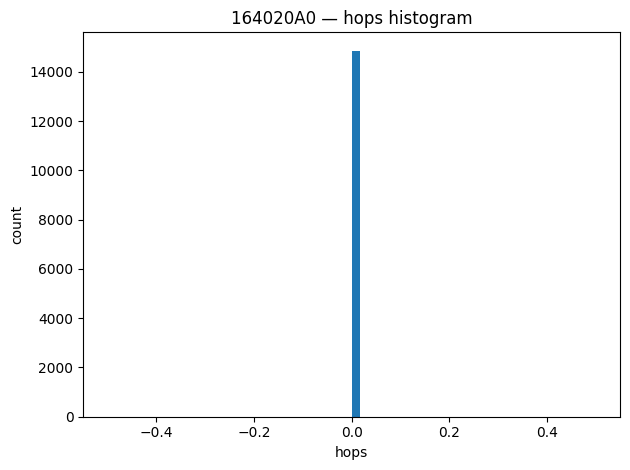

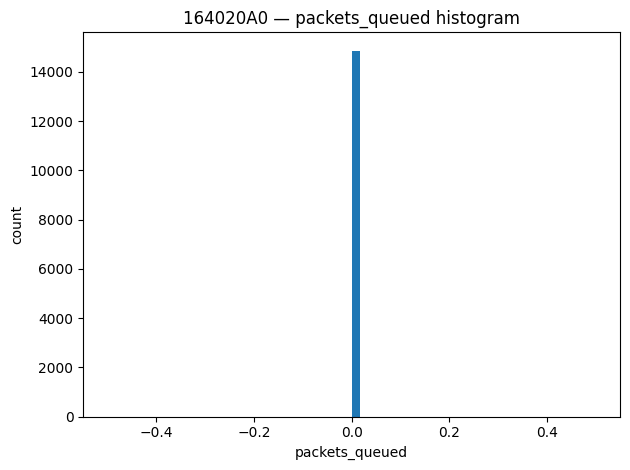


Correlation matrix for 164020A0 (daily medians; vars with <50% missing):
                                    hops  intervals_active  mesh_parent  radio_signal_strength_incoming_dbm  radio_signal_strength_outgoing_dbm  packets_queued  type  encryption_id  interval_s  mesh_timeout_s  radio_frequency  radio_signal_sensitivity_dbm  mesh_radio_relay_factor  transmit_power_dbm  radio_connection_group  mesh_batt_v  temp_c
hops                                 NaN               NaN          NaN                                 NaN                                 NaN             NaN   NaN            NaN         NaN             NaN              NaN                           NaN                      NaN                 NaN                     NaN          NaN     NaN
intervals_active                     NaN             1.000          NaN                                 NaN                                 NaN             NaN   NaN            NaN      -0.064           0.082              NaN         

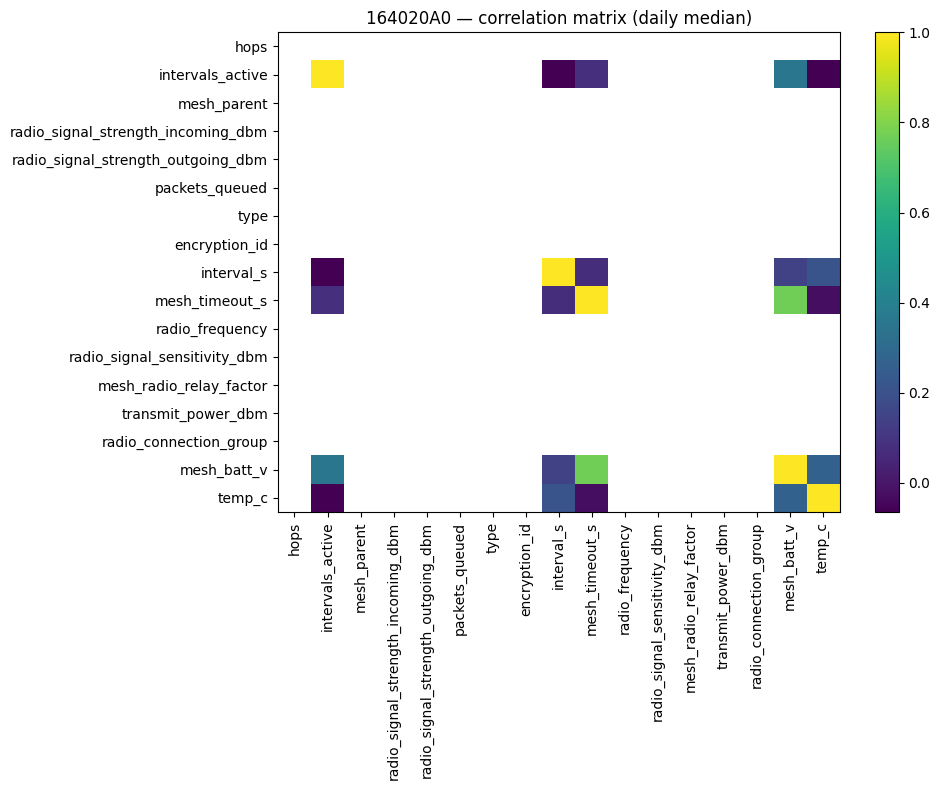

In [5]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PATH = "/datassd/proyectos/terravision/terravision_sensor_data/tharsis/tilt/tharsis_tilt_metadata.nc"

# ----------------------------
# 1) Load + basic cleaning
# ----------------------------
ds = xr.open_dataset(PATH)

# Drop NaT times, sort by time
time = pd.to_datetime(ds["time"].values)
valid = ~time.isna()
ds = ds.isel(time=valid).sortby("time")

# Drop duplicate timestamps per sensor (keep first)
df0 = ds[["serial_number"]].to_dataframe().reset_index()
dup_mask = df0.duplicated(subset=["serial_number", "time"], keep="first")
if dup_mask.any():
    ds = ds.isel(time=~xr.DataArray(dup_mask.values, dims="time"))

print("Dataset:", ds)
print("\nVariables:", list(ds.data_vars))
print("\nTime range:", pd.to_datetime(ds.time.values[0]), "→", pd.to_datetime(ds.time.values[-1]))
print("N time steps:", ds.sizes["time"])

# Identify variable types
all_vars = list(ds.data_vars)
cat_vars = [v for v in all_vars if ds[v].dtype.kind in {"U", "S", "O"}]
num_vars = [v for v in all_vars if np.issubdtype(ds[v].dtype, np.number)]

print("\nCategorical vars:", cat_vars)
print("Numeric vars:", num_vars)

# ----------------------------
# 2) Sensor inventory
# ----------------------------
df_meta = ds[["serial_number"]].to_dataframe().reset_index()
counts = df_meta["serial_number"].value_counts()

print("\nSensors (serial_number) counts:")
print(counts.to_string())

top_serial = counts.index[0]
print("\nUsing top sensor for plots/corr:", top_serial)

# ----------------------------
# 3) Cadence + gaps (PER SENSOR)
# ----------------------------
gap_threshold = pd.Timedelta(minutes=30)

gap_rows = []
cad_rows = []

for sn in counts.index:
    t_sn = df_meta.loc[df_meta["serial_number"] == sn, "time"].sort_values()
    dt = t_sn.diff().dropna()

    if len(dt) == 0:
        continue

    cad_rows.append({
        "serial_number": sn,
        "n_points": int((df_meta["serial_number"] == sn).sum()),
        "dt_median": dt.median(),
        "dt_p25": dt.quantile(0.25),
        "dt_p75": dt.quantile(0.75),
        "dt_max": dt.max(),
    })

    gaps = dt[dt > gap_threshold].sort_values(ascending=False)
    if len(gaps):
        t_sn = t_sn.reset_index(drop=True)
        dt_pos = t_sn.diff()
        gap_pos = dt_pos[dt_pos > gap_threshold]

        for pos, gap in gap_pos.sort_values(ascending=False).head(10).items():
            time_after = t_sn.iloc[pos]
            time_before = t_sn.iloc[pos - 1] if pos > 0 else pd.NaT

            gap_rows.append({
                "serial_number": sn,
                "gap": str(gap),
                "time_before_gap": time_before,
                "time_after_gap": time_after,
            })

cad_df = pd.DataFrame(cad_rows).sort_values(["dt_median", "serial_number"])
print("\nCadence summary per sensor:")
print(cad_df.to_string(index=False))

if gap_rows:
    gaps_df = pd.DataFrame(gap_rows)
    print(f"\nFound gaps > {gap_threshold} (top 10 per sensor):")
    print(gaps_df.to_string(index=False))
else:
    print(f"\nNo gaps > {gap_threshold} found (per sensor).")

# ----------------------------
# 4) Missingness + stats per variable (NUMERIC ONLY)
# ----------------------------
missing_rows = []
stats_rows = []

for v in num_vars:
    arr = ds[v].values.astype("float64")
    n = arr.size
    n_missing = int(np.isnan(arr).sum())
    missing_pct = (n_missing / n) * 100
    missing_rows.append({"variable": v, "missing_count": n_missing, "missing_pct": missing_pct})

    if n_missing == n:
        stats_rows.append({"variable": v, "dtype": str(ds[v].dtype)})
        continue

    s = pd.Series(arr)
    stats_rows.append({
        "variable": v,
        "dtype": str(ds[v].dtype),
        "min": float(np.nanmin(arr)),
        "p01": float(s.quantile(0.01)),
        "p05": float(s.quantile(0.05)),
        "median": float(np.nanmedian(arr)),
        "mean": float(np.nanmean(arr)),
        "std": float(np.nanstd(arr)),
        "p95": float(s.quantile(0.95)),
        "p99": float(s.quantile(0.99)),
        "max": float(np.nanmax(arr)),
    })

missing_df = pd.DataFrame(missing_rows).sort_values(["missing_pct", "variable"], ascending=[False, True])
stats_df = pd.DataFrame(stats_rows).sort_values("variable")

print("\nMissingness (numeric vars):")
print(missing_df.to_string(index=False))

print("\nStats (numeric vars):")
print(stats_df.to_string(index=False))

# ----------------------------
# 5) Time series plots (daily) — FOR ONE SENSOR
# ----------------------------
preferred_order = [
    # tilt / orientation
    "x_mm_per_m", "y_mm_per_m", "z_mm_per_m",
    "x_g", "y_g", "z_g",
    # device health / comms
    "temp_c", "mesh_batt_v", "ref_v",
    "radio_signal_strength_incoming_dbm", "radio_signal_strength_outgoing_dbm",
    "hops", "packets_queued",
]

good_vars = missing_df.loc[missing_df["missing_pct"] < 100, "variable"].tolist()
plot_vars = [v for v in preferred_order if v in good_vars][:6] or good_vars[:6]

df = ds[["serial_number"] + plot_vars].to_dataframe().reset_index()
df = df[df["serial_number"] == top_serial].set_index("time").sort_index()

for v in plot_vars:
    series = df[v].astype("float64")
    plt.figure()
    daily = series.resample("1D").median()  # median is often nicer for tilt/noise
    plt.plot(daily.index, daily.values)
    plt.title(f"{top_serial} — {v} (daily median)")
    plt.xlabel("date")
    plt.ylabel(v)
    plt.tight_layout()
    plt.show()

# ----------------------------
# 6) Histograms (one sensor)
# ----------------------------
for v in plot_vars:
    s = df[v].dropna()
    if len(s) == 0:
        continue
    plt.figure()
    plt.hist(s.values, bins=60)
    plt.title(f"{top_serial} — {v} histogram")
    plt.xlabel(v)
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()

# ----------------------------
# 7) Correlation matrix (numeric vars with <50% missing) — one sensor
# ----------------------------
missing_map = missing_df.set_index("variable")["missing_pct"].to_dict()
corr_vars = [v for v in num_vars if missing_map.get(v, 100) < 50]

df_corr = ds[["serial_number"] + corr_vars].to_dataframe().reset_index()
df_corr = df_corr[df_corr["serial_number"] == top_serial].drop(columns=["serial_number"]).set_index("time")

# Optional: use daily aggregation to reduce autocorrelation / burstiness
df_daily = df_corr.resample("1D").median()

corr = df_daily.corr(numeric_only=True)

print(f"\nCorrelation matrix for {top_serial} (daily medians; vars with <50% missing):")
print(corr.round(3).to_string())

plt.figure(figsize=(10, 8))
plt.imshow(corr.values, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title(f"{top_serial} — correlation matrix (daily median)")
plt.tight_layout()
plt.show()

Dataset: <xarray.Dataset> Size: 5MB
Dimensions:                             (time: 25939)
Coordinates:
  * time                                (time) datetime64[ns] 208kB 2023-08-0...
Data variables: (12/18)
    serial_number                       (time) <U8 830kB '16221F19' ... '1622...
    hops                                (time) float64 208kB ...
    intervals_active                    (time) int64 208kB ...
    mesh_parent                         (time) <U8 830kB ...
    radio_signal_strength_incoming_dbm  (time) float64 208kB ...
    radio_signal_strength_outgoing_dbm  (time) float64 208kB ...
    ...                                  ...
    x_g                                 (time) float64 208kB ...
    y_g                                 (time) float64 208kB ...
    z_g                                 (time) float64 208kB ...
    x_mm_per_m                          (time) float64 208kB ...
    y_mm_per_m                          (time) float64 208kB ...
    z_mm_per_m        

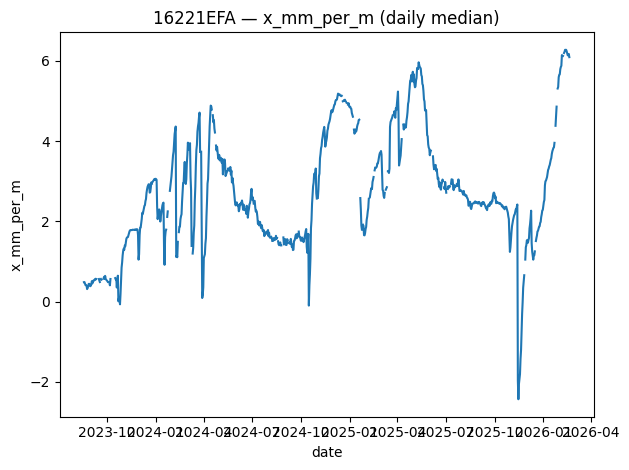

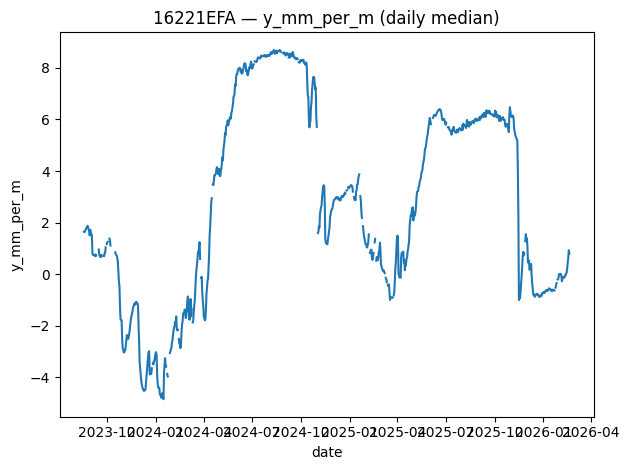

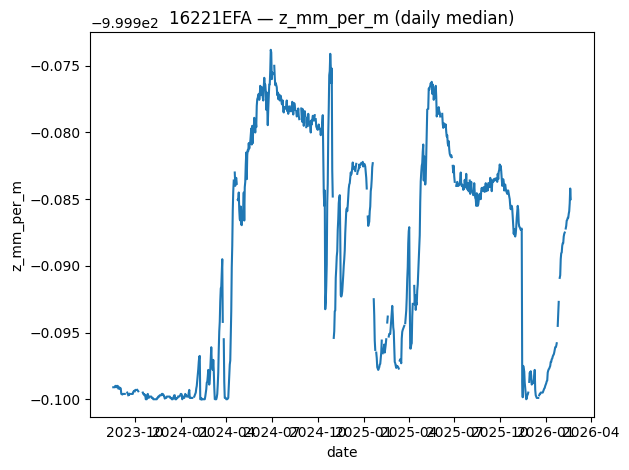

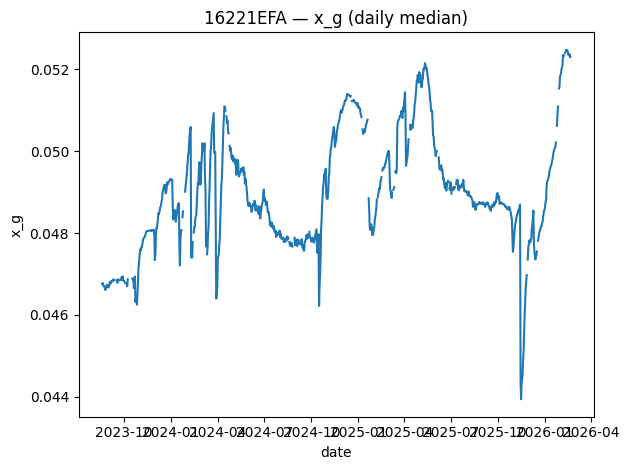

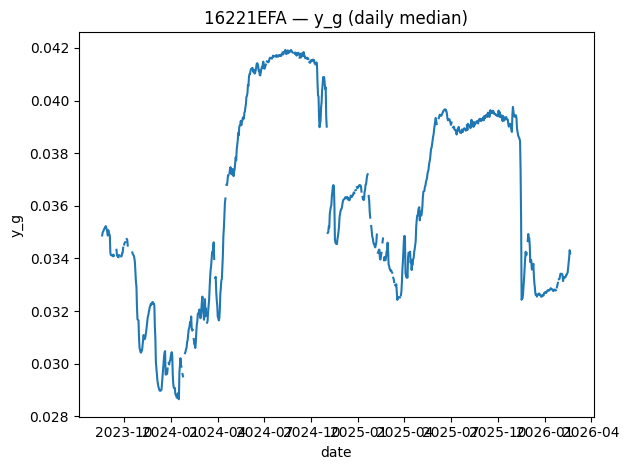

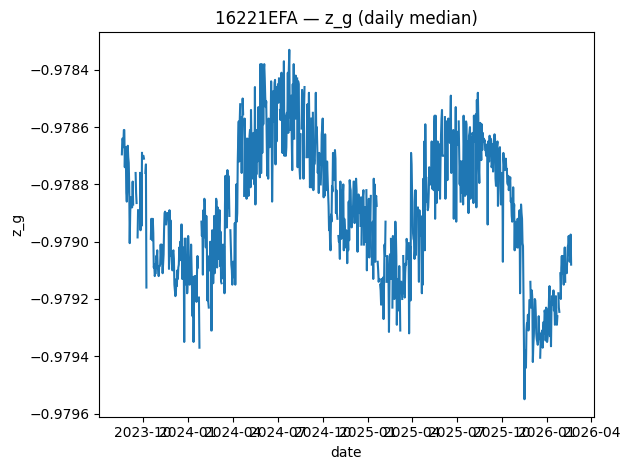

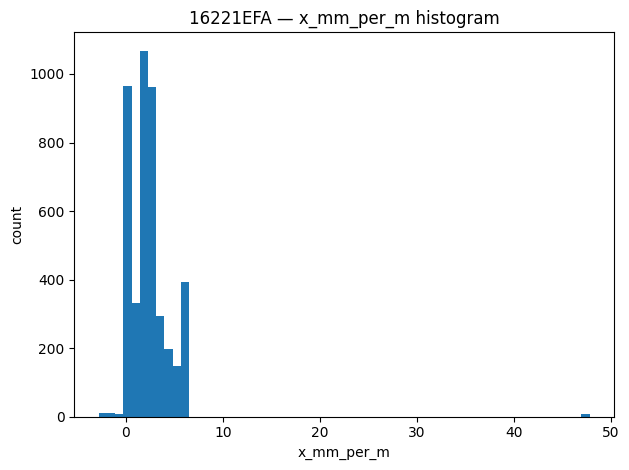

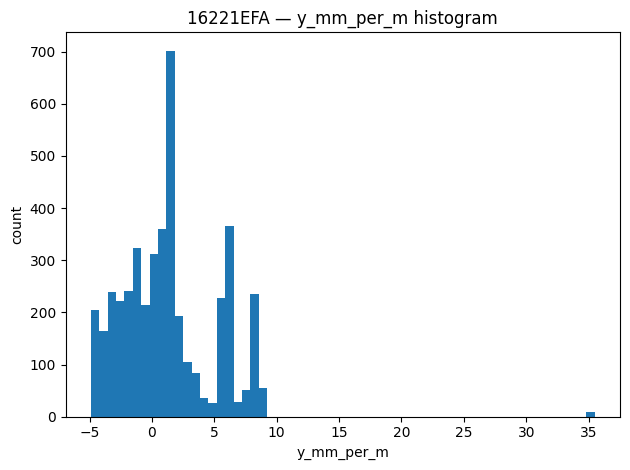

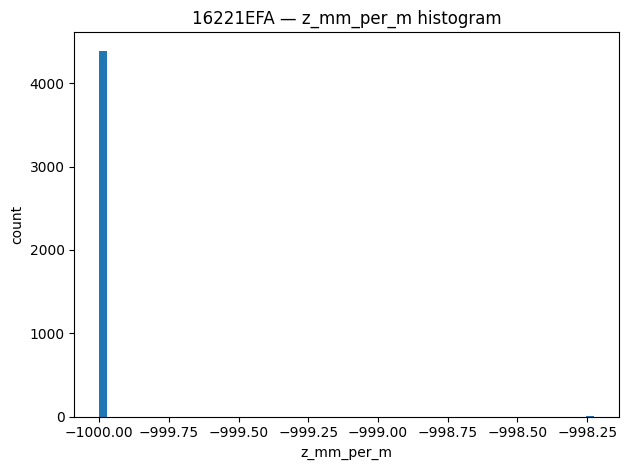

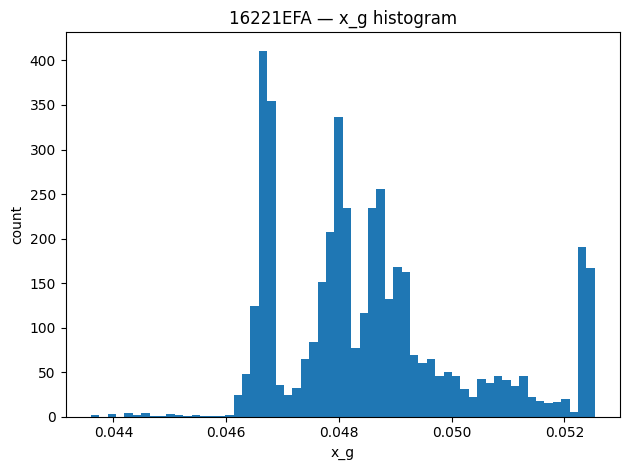

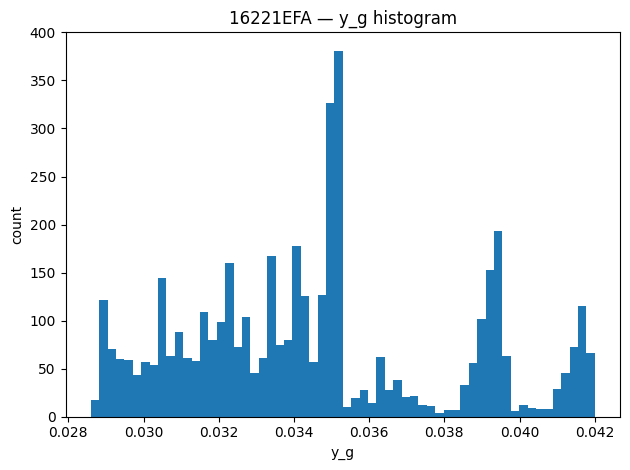

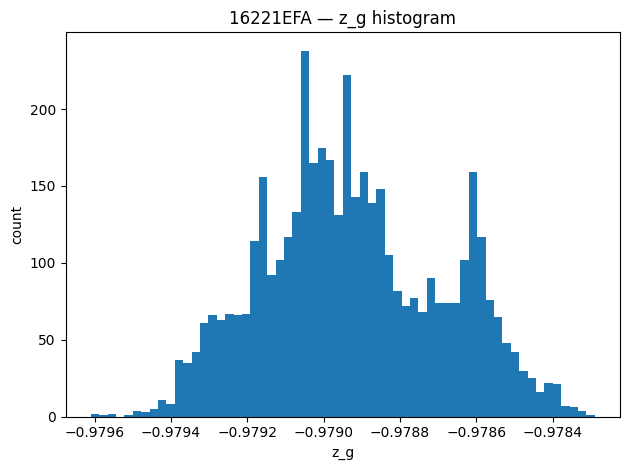


Correlation matrix for 16221EFA (daily medians; vars with <50% missing):
                                    hops  intervals_active  radio_signal_strength_incoming_dbm  radio_signal_strength_outgoing_dbm  packets_queued  type  radio_connection_group  mesh_batt_v  ref_v  temp_c    x_g    y_g    z_g  x_mm_per_m  y_mm_per_m  z_mm_per_m
hops                                 NaN               NaN                                 NaN                                 NaN             NaN   NaN                     NaN          NaN    NaN     NaN    NaN    NaN    NaN         NaN         NaN         NaN
intervals_active                     NaN             1.000                               0.578                               0.467             NaN   NaN                     NaN       -0.380 -0.172   0.226  0.151  0.490  0.374       0.152       0.489       0.510
radio_signal_strength_incoming_dbm   NaN             0.578                               1.000                               0.951          

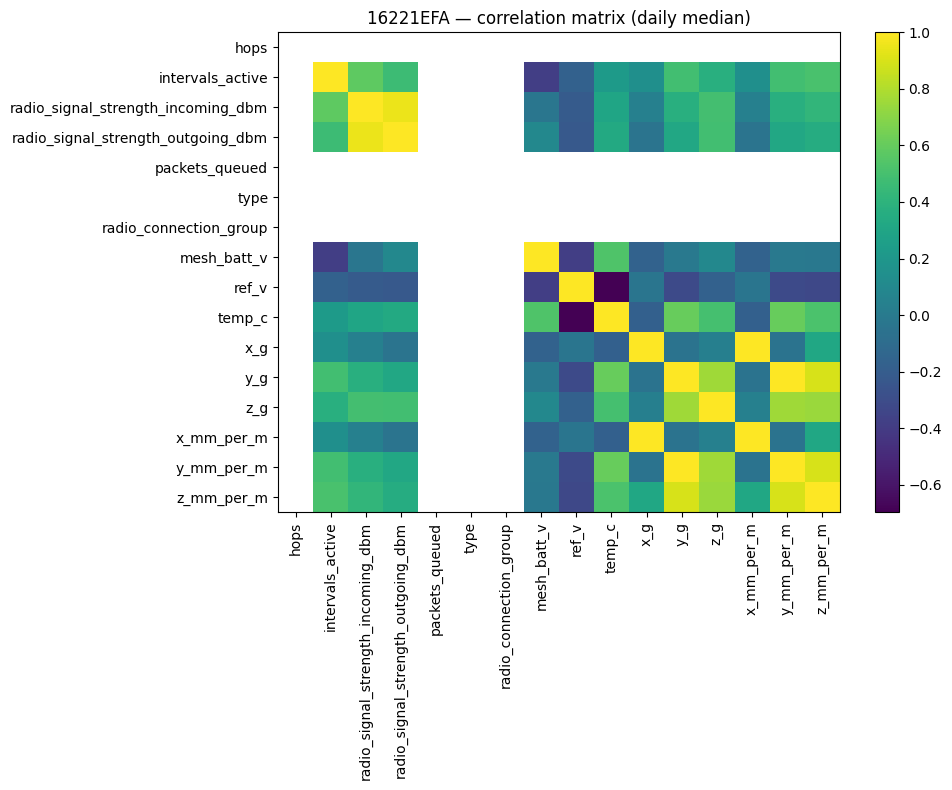

In [ ]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PATH = "/datassd/proyectos/terravision/terravision_sensor_data/tharsis/tilt/tharsis_tilt.nc"

# ----------------------------
# 1) Load + basic cleaning
# ----------------------------
ds = xr.open_dataset(PATH)

# Drop NaT times, sort by time
time = pd.to_datetime(ds["time"].values)
valid = ~time.isna()
ds = ds.isel(time=valid).sortby("time")

# Drop duplicate timestamps per sensor (keep first)
df0 = ds[["serial_number"]].to_dataframe().reset_index()
dup_mask = df0.duplicated(subset=["serial_number", "time"], keep="first")
if dup_mask.any():
    ds = ds.isel(time=~xr.DataArray(dup_mask.values, dims="time"))

print("Dataset:", ds)
print("\nVariables:", list(ds.data_vars))
print("\nTime range:", pd.to_datetime(ds.time.values[0]), "→", pd.to_datetime(ds.time.values[-1]))
print("N time steps:", ds.sizes["time"])

# Identify variable types
all_vars = list(ds.data_vars)
cat_vars = [v for v in all_vars if ds[v].dtype.kind in {"U", "S", "O"}]
num_vars = [v for v in all_vars if np.issubdtype(ds[v].dtype, np.number)]

print("\nCategorical vars:", cat_vars)
print("Numeric vars:", num_vars)

# ----------------------------
# 2) Sensor inventory
# ----------------------------
df_meta = ds[["serial_number"]].to_dataframe().reset_index()
counts = df_meta["serial_number"].value_counts()

print("\nSensors (serial_number) counts:")
print(counts.to_string())

top_serial = counts.index[0]
print("\nUsing top sensor for plots/corr:", top_serial)

# ----------------------------
# 3) Cadence + gaps (PER SENSOR)
# ----------------------------
gap_threshold = pd.Timedelta(minutes=30)

gap_rows = []
cad_rows = []

for sn in counts.index:
    t_sn = df_meta.loc[df_meta["serial_number"] == sn, "time"].sort_values()
    dt = t_sn.diff().dropna()

    if len(dt) == 0:
        continue

    cad_rows.append({
        "serial_number": sn,
        "n_points": int((df_meta["serial_number"] == sn).sum()),
        "dt_median": dt.median(),
        "dt_p25": dt.quantile(0.25),
        "dt_p75": dt.quantile(0.75),
        "dt_max": dt.max(),
    })

    gaps = dt[dt > gap_threshold].sort_values(ascending=False)
    if len(gaps):
        t_sn = t_sn.reset_index(drop=True)
        dt_pos = t_sn.diff()
        gap_pos = dt_pos[dt_pos > gap_threshold]

        for pos, gap in gap_pos.sort_values(ascending=False).head(10).items():
            time_after = t_sn.iloc[pos]
            time_before = t_sn.iloc[pos - 1] if pos > 0 else pd.NaT

            gap_rows.append({
                "serial_number": sn,
                "gap": str(gap),
                "time_before_gap": time_before,
                "time_after_gap": time_after,
            })

cad_df = pd.DataFrame(cad_rows).sort_values(["dt_median", "serial_number"])
print("\nCadence summary per sensor:")
print(cad_df.to_string(index=False))

if gap_rows:
    gaps_df = pd.DataFrame(gap_rows)
    print(f"\nFound gaps > {gap_threshold} (top 10 per sensor):")
    print(gaps_df.to_string(index=False))
else:
    print(f"\nNo gaps > {gap_threshold} found (per sensor).")

# ----------------------------
# 4) Missingness + stats per variable (NUMERIC ONLY)
# ----------------------------
missing_rows = []
stats_rows = []

for v in num_vars:
    arr = ds[v].values.astype("float64")
    n = arr.size
    n_missing = int(np.isnan(arr).sum())
    missing_pct = (n_missing / n) * 100
    missing_rows.append({"variable": v, "missing_count": n_missing, "missing_pct": missing_pct})

    if n_missing == n:
        stats_rows.append({"variable": v, "dtype": str(ds[v].dtype)})
        continue

    s = pd.Series(arr)
    stats_rows.append({
        "variable": v,
        "dtype": str(ds[v].dtype),
        "min": float(np.nanmin(arr)),
        "p01": float(s.quantile(0.01)),
        "p05": float(s.quantile(0.05)),
        "median": float(np.nanmedian(arr)),
        "mean": float(np.nanmean(arr)),
        "std": float(np.nanstd(arr)),
        "p95": float(s.quantile(0.95)),
        "p99": float(s.quantile(0.99)),
        "max": float(np.nanmax(arr)),
    })

missing_df = pd.DataFrame(missing_rows).sort_values(["missing_pct", "variable"], ascending=[False, True])
stats_df = pd.DataFrame(stats_rows).sort_values("variable")

print("\nMissingness (numeric vars):")
print(missing_df.to_string(index=False))

print("\nStats (numeric vars):")
print(stats_df.to_string(index=False))

# ----------------------------
# 5) Time series plots (daily) — FOR ONE SENSOR
# ----------------------------
preferred_order = [
    # tilt / orientation
    "x_mm_per_m", "y_mm_per_m", "z_mm_per_m",
    "x_g", "y_g", "z_g",
    # device health / comms
    "temp_c", "mesh_batt_v", "ref_v",
    "radio_signal_strength_incoming_dbm", "radio_signal_strength_outgoing_dbm",
    "hops", "packets_queued",
]

good_vars = missing_df.loc[missing_df["missing_pct"] < 100, "variable"].tolist()
plot_vars = [v for v in preferred_order if v in good_vars][:6] or good_vars[:6]

df = ds[["serial_number"] + plot_vars].to_dataframe().reset_index()
df = df[df["serial_number"] == top_serial].set_index("time").sort_index()

for v in plot_vars:
    series = df[v].astype("float64")
    plt.figure()
    daily = series.resample("1D").median()  # median is often nicer for tilt/noise
    plt.plot(daily.index, daily.values)
    plt.title(f"{top_serial} — {v} (daily median)")
    plt.xlabel("date")
    plt.ylabel(v)
    plt.tight_layout()
    plt.show()

# ----------------------------
# 6) Histograms (one sensor)
# ----------------------------
for v in plot_vars:
    s = df[v].dropna()
    if len(s) == 0:
        continue
    plt.figure()
    plt.hist(s.values, bins=60)
    plt.title(f"{top_serial} — {v} histogram")
    plt.xlabel(v)
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()

# ----------------------------
# 7) Correlation matrix (numeric vars with <50% missing) — one sensor
# ----------------------------
missing_map = missing_df.set_index("variable")["missing_pct"].to_dict()
corr_vars = [v for v in num_vars if missing_map.get(v, 100) < 50]

df_corr = ds[["serial_number"] + corr_vars].to_dataframe().reset_index()
df_corr = df_corr[df_corr["serial_number"] == top_serial].drop(columns=["serial_number"]).set_index("time")

# Optional: use daily aggregation to reduce autocorrelation / burstiness
df_daily = df_corr.resample("1D").median()

corr = df_daily.corr(numeric_only=True)

print(f"\nCorrelation matrix for {top_serial} (daily medians; vars with <50% missing):")
print(corr.round(3).to_string())

plt.figure(figsize=(10, 8))
plt.imshow(corr.values, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title(f"{top_serial} — correlation matrix (daily median)")
plt.tight_layout()
plt.show()